# (h_each, h_mean) 진단 평면 — 4가지 설정의 궤적

노트북 5절의 `train`을 centering / sharpening 조합 4가지로 실제로 돌리고,
학습 스텝마다 기록된 `(h_each, h_mean)` 쌍을 **2D 진단 평면 위의 궤적**으로 그린다.

핵심 기하:
- Jensen에 의해 항상 `h_mean >= h_each` → **대각선 위쪽 삼각형만 도달 가능**
- 대각선까지의 수직 거리 `h_mean - h_each` = 상호정보 $I(X;Z)$
- 원점 = 원-핫 붕괴, $(\log K, \log K)$ = 균등 붕괴, 좌상단 = 건강

In [1]:
import math, copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def _show(fig):
    try:
        from IPython import get_ipython
        if get_ipython() is not None:
            fig.show()
    except ImportError:
        pass


torch.manual_seed(0)
print("torch", torch.__version__)

torch 2.4.0+cu121


## 1. 노트북 5절 재현 (MiniDINOLoss + 토이 데이터 + train)

In [2]:
def entropy(p):
    return -(p * p.clamp_min(1e-12).log()).sum(-1)


class MiniDINOLoss(nn.Module):
    def __init__(self, out_dim, ncrops, teacher_temp, student_temp=0.1,
                 center_momentum=0.9, use_center=True):
        super().__init__()
        self.student_temp = student_temp
        self.teacher_temp = teacher_temp
        self.center_momentum = center_momentum
        self.ncrops = ncrops
        self.use_center = use_center
        self.register_buffer("center", torch.zeros(1, out_dim))

    def forward(self, student_output, teacher_output):
        student_out = (student_output / self.student_temp).chunk(self.ncrops)
        center = self.center if self.use_center else 0.0
        teacher_out = F.softmax((teacher_output - center) / self.teacher_temp, dim=-1)
        teacher_out = teacher_out.detach().chunk(2)
        total_loss, n_terms = 0.0, 0
        for iq, q in enumerate(teacher_out):
            for v in range(len(student_out)):
                if v == iq:
                    continue
                loss = torch.sum(-q * F.log_softmax(student_out[v], dim=-1), dim=-1)
                total_loss += loss.mean()
                n_terms += 1
        total_loss /= n_terms
        self.update_center(teacher_output)
        return total_loss

    @torch.no_grad()
    def update_center(self, teacher_output):
        batch_center = teacher_output.mean(dim=0, keepdim=True)
        self.center = self.center * self.center_momentum + batch_center * (1 - self.center_momentum)


def make_data(n_per_cluster=128, n_clusters=6, radius=3.0, spread=0.3, seed=0):
    g = torch.Generator().manual_seed(seed)
    angles = torch.arange(n_clusters) * (2 * math.pi / n_clusters)
    centers = torch.stack([radius * angles.cos(), radius * angles.sin()], -1)
    X = (centers[:, None, :] + spread * torch.randn(n_clusters, n_per_cluster, 2, generator=g)).reshape(-1, 2)
    y = torch.arange(n_clusters).repeat_interleave(n_per_cluster)
    return X, y


X, y = make_data()
N_CLUSTERS = 6


def augment(x, sigma=0.7):
    return x + sigma * torch.randn_like(x)


def mlp(in_dim=2, out_dim=32, hidden=128):
    return nn.Sequential(
        nn.Linear(in_dim, hidden), nn.GELU(),
        nn.Linear(hidden, hidden), nn.GELU(),
        nn.Linear(hidden, out_dim),
    )


@torch.no_grad()
def code_metrics(q, labels):
    codes = q.argmax(-1)
    counts = codes.bincount(minlength=q.shape[-1])
    top_share = counts.max().item() / len(codes)
    correct = sum(labels[codes == c].bincount().max().item() for c in codes.unique())
    return top_share, correct / len(labels)


@torch.no_grad()
def teacher_dist(teacher, loss_fn, use_center, teacher_temp):
    logits = teacher(X)
    center = loss_fn.center if use_center else 0.0
    return F.softmax((logits - center) / teacher_temp, -1)


def train(use_center, teacher_temp, steps=1500, out_dim=32, m=0.99, lr=1e-3,
          batch=256, log_every=25, seed=0):
    torch.manual_seed(seed)
    student = mlp(out_dim=out_dim)
    teacher = copy.deepcopy(student)
    for p in teacher.parameters():
        p.requires_grad_(False)
    opt = torch.optim.Adam(student.parameters(), lr=lr)
    loss_fn = MiniDINOLoss(out_dim, ncrops=2, teacher_temp=teacher_temp, use_center=use_center)

    hist = {k: [] for k in ["step", "loss", "h_each", "h_mean", "top_share", "code_acc"]}
    for step in range(steps):
        idx = torch.randint(0, len(X), (batch,))
        views = torch.cat([augment(X[idx]), augment(X[idx])])
        s_out = student(views)
        with torch.no_grad():
            t_out = teacher(views)
        loss = loss_fn(s_out, t_out)

        opt.zero_grad(); loss.backward(); opt.step()

        with torch.no_grad():
            for ps, pt in zip(student.parameters(), teacher.parameters()):
                pt.mul_(m).add_((1 - m) * ps)

        if step % log_every == 0 or step == steps - 1:
            q = teacher_dist(teacher, loss_fn, use_center, teacher_temp)
            top, acc = code_metrics(q, y)
            hist["step"].append(step)
            hist["loss"].append(loss.item())
            hist["h_each"].append(entropy(q).mean().item())
            hist["h_mean"].append(entropy(q.mean(0)).item())
            hist["top_share"].append(top)
            hist["code_acc"].append(acc)
    return hist, teacher, loss_fn


LOG_K = math.log(32)
LOG_C = math.log(N_CLUSTERS)
print(f"log K = log 32 = {LOG_K:.3f}   log 6 = {LOG_C:.3f}")

log K = log 32 = 3.466   log 6 = 1.792


## 2. 4가지 설정 학습 (각 1500 step)

In [3]:
configs = {
    "none        (center off, temp 0.10)": dict(use_center=False, teacher_temp=0.1),
    "center only (center on,  temp 0.10)": dict(use_center=True,  teacher_temp=0.1),
    "sharp only  (center off, temp 0.04)": dict(use_center=False, teacher_temp=0.04),
    "both = DINO (center on,  temp 0.04)": dict(use_center=True,  teacher_temp=0.04),
}
COLORS = {
    "none        (center off, temp 0.10)": "#64748b",   # slate
    "center only (center on,  temp 0.10)": "#f59e0b",   # amber
    "sharp only  (center off, temp 0.04)": "#8b5cf6",   # violet
    "both = DINO (center on,  temp 0.04)": "#10b981",   # emerald
}

results, models = {}, {}
print(f"{'config':38s} {'h_each':>7s} {'h_mean':>7s} {'gap=I':>7s} {'top_sh':>7s} {'acc':>6s}")
for name, cfg in configs.items():
    hist, teacher, loss_fn = train(**cfg)
    results[name], models[name] = hist, (teacher, loss_fn, cfg)
    he, hm = hist["h_each"][-1], hist["h_mean"][-1]
    print(f"{name:38s} {he:7.3f} {hm:7.3f} {hm - he:7.3f} "
          f"{hist['top_share'][-1]:7.2f} {hist['code_acc'][-1]:6.2f}")

config                                  h_each  h_mean   gap=I  top_sh    acc
none        (center off, temp 0.10)      2.901   3.008   0.106    0.83   0.33
center only (center on,  temp 0.10)      3.355   3.463   0.108    0.33   0.83
sharp only  (center off, temp 0.04)      0.003   1.242   1.240    0.50   0.67
both = DINO (center on,  temp 0.04)      0.587   2.376   1.789    0.17   1.00


## 3. Jensen 부등식이 실제로 지켜지는지 확인

기록된 모든 (config, step) 쌍에 대해 `h_mean - h_each >= 0` 이어야 한다.

In [4]:
gaps = np.concatenate([np.array(r["h_mean"]) - np.array(r["h_each"]) for r in results.values()])
print(f"기록된 점 {gaps.size}개 중 gap < 0 인 점: {(gaps < -1e-6).sum()}개")
print(f"gap 범위: [{gaps.min():.4f}, {gaps.max():.4f}]   (이론 상한 log 6 = {LOG_C:.3f} 근처)")

기록된 점 244개 중 gap < 0 인 점: 0개
gap 범위: [0.1065, 1.7893]   (이론 상한 log 6 = 1.792 근처)


## 4. 진단 평면 + 대각선 거리 + 최종 코드 사용 히스토그램

In [5]:
fig = make_subplots(
    rows=2, cols=4,
    specs=[[{"colspan": 2, "rowspan": 1}, None, {"colspan": 2}, None],
           [{}, {}, {}, {}]],
    row_heights=[0.66, 0.34],
    vertical_spacing=0.13, horizontal_spacing=0.055,
    subplot_titles=(
        "진단 평면: (h_each, h_mean) 궤적",
        "대각선까지의 거리 = h_mean − h_each ≈ I(X;Z)",
        *[n.split("(")[0].strip() for n in configs],
    ),
)

# --- (a) 진단 평면 -----------------------------------------------------------
L = LOG_K
# Jensen 금지 영역 (대각선 아래)
fig.add_trace(go.Scatter(
    x=[0, L, L, 0], y=[0, 0, L, 0], fill="toself",
    fillcolor="rgba(148,163,184,0.22)", line=dict(width=0),
    hoverinfo="skip", showlegend=False), row=1, col=1)
fig.add_trace(go.Scatter(
    x=[0, L], y=[0, L], mode="lines",
    line=dict(color="#475569", width=1.6, dash="dash"),
    name="y = x (Jensen 경계, I = 0)"), row=1, col=1)
# log K 경계 (균등 붕괴 코너)
for ax_kw in (dict(x=[L, L], y=[0, L]), dict(x=[0, L], y=[L, L])):
    fig.add_trace(go.Scatter(**ax_kw, mode="lines",
                             line=dict(color="#cbd5e1", width=1),
                             hoverinfo="skip", showlegend=False), row=1, col=1)
# log 6 기준선 (건강한 h_mean 눈금)
fig.add_trace(go.Scatter(
    x=[0, L], y=[LOG_C, LOG_C], mode="lines",
    line=dict(color="#0ea5e9", width=1, dash="dot"),
    name="h_mean = log 6 (클러스터 수)"), row=1, col=1)

for name, r in results.items():
    he, hm, st = np.array(r["h_each"]), np.array(r["h_mean"]), np.array(r["step"])
    op = 0.18 + 0.82 * (st / st.max())            # 스텝이 진행될수록 진하게
    c = COLORS[name]
    fig.add_trace(go.Scatter(
        x=he, y=hm, mode="lines", line=dict(color=c, width=1.2),
        opacity=0.45, hoverinfo="skip", showlegend=False), row=1, col=1)
    fig.add_trace(go.Scatter(
        x=he, y=hm, mode="markers",
        marker=dict(color=c, size=6, opacity=op, line=dict(width=0)),
        name=name, legendgroup=name,
        customdata=st, hovertemplate="step %{customdata}<br>h_each %{x:.3f}<br>h_mean %{y:.3f}<extra></extra>"),
        row=1, col=1)
    fig.add_trace(go.Scatter(                      # 시작점 = 원
        x=[he[0]], y=[hm[0]], mode="markers",
        marker=dict(color="white", size=11, symbol="circle",
                    line=dict(color=c, width=2.4)),
        legendgroup=name, showlegend=False,
        hovertemplate=f"{name}<br>START<extra></extra>"), row=1, col=1)
    fig.add_trace(go.Scatter(                      # 끝점 = 별
        x=[he[-1]], y=[hm[-1]], mode="markers",
        marker=dict(color=c, size=17, symbol="star",
                    line=dict(color="white", width=1.2)),
        legendgroup=name, showlegend=False,
        hovertemplate=f"{name}<br>END<extra></extra>"), row=1, col=1)

for txt, xx, yy, col in [("one-hot collapse", 0.05, 0.13, "#b91c1c"),
                         ("uniform collapse", L - 0.05, L - 0.10, "#b45309"),
                         ("HEALTHY", 0.10, L - 0.55, "#047857"),
                         ("impossible (Jensen)", L - 0.35, 0.55, "#64748b")]:
    fig.add_annotation(x=xx, y=yy, text=f"<b>{txt}</b>", showarrow=False,
                       font=dict(size=11, color=col),
                       xanchor="left" if xx < L / 2 else "right",
                       row=1, col=1)
_b = "both = DINO (center on,  temp 0.04)"
_bx, _by = results[_b]["h_each"][-1], results[_b]["h_mean"][-1]
fig.add_trace(go.Scatter(                          # 대각선까지의 수직 거리 = I(X;Z)
    x=[_bx, _bx], y=[_bx, _by], mode="lines",
    line=dict(color="#047857", width=2.5),
    hoverinfo="skip", showlegend=False), row=1, col=1)
fig.add_annotation(x=_bx, y=(_bx + _by) / 2, ax=42, ay=0,
                   text="gap = I(X;Z)", showarrow=True,
                   arrowhead=2, arrowwidth=1.6, arrowcolor="#047857",
                   xanchor="left", font=dict(size=11, color="#047857"), row=1, col=1)

# --- (b) 대각선 거리 곡선 -----------------------------------------------------
for name, r in results.items():
    fig.add_trace(go.Scatter(
        x=r["step"], y=np.array(r["h_mean"]) - np.array(r["h_each"]),
        mode="lines", line=dict(color=COLORS[name], width=2),
        legendgroup=name, showlegend=False,
        hovertemplate="step %{x}<br>I ≈ %{y:.3f}<extra></extra>"), row=1, col=3)
fig.add_hline(y=LOG_C, line=dict(color="#0ea5e9", width=1, dash="dot"), row=1, col=3)
fig.add_annotation(x=1500, y=LOG_C, text="log 6 = 1.79", showarrow=False, yshift=10,
                   xanchor="right", font=dict(size=10, color="#0ea5e9"), row=1, col=3)

# --- (c) 최종 코드 사용 히스토그램 ---------------------------------------------
print("\n최종 코드 사용 (32개 prototype 중):")
for j, (name, (teacher, loss_fn, cfg)) in enumerate(models.items(), start=1):
    q = teacher_dist(teacher, loss_fn, **cfg)
    counts = q.argmax(-1).bincount(minlength=32).numpy()
    used = int((counts > 0).sum())
    print(f"  {name:38s} 사용 코드 {used:2d}개, 최대 코드 점유 {counts.max() / counts.sum():.2f}")
    fig.add_trace(go.Bar(
        x=list(range(32)), y=counts, marker_color=COLORS[name],
        showlegend=False, hovertemplate="code %{x}<br>%{y} points<extra></extra>"),
        row=2, col=j)
    fig.add_annotation(xref="x domain", yref="y domain", x=0.5, y=1.0,
                       text=f"<b>{used} codes used · top {counts.max() / counts.sum():.2f}</b>",
                       showarrow=False, xanchor="center", yanchor="top",
                       font=dict(size=12, color=COLORS[name]), row=2, col=j)


최종 코드 사용 (32개 prototype 중):
  none        (center off, temp 0.10)    사용 코드  2개, 최대 코드 점유 0.83
  center only (center on,  temp 0.10)    사용 코드  6개, 최대 코드 점유 0.33
  sharp only  (center off, temp 0.04)    사용 코드  4개, 최대 코드 점유 0.50
  both = DINO (center on,  temp 0.04)    사용 코드  6개, 최대 코드 점유 0.17


saved expy.png


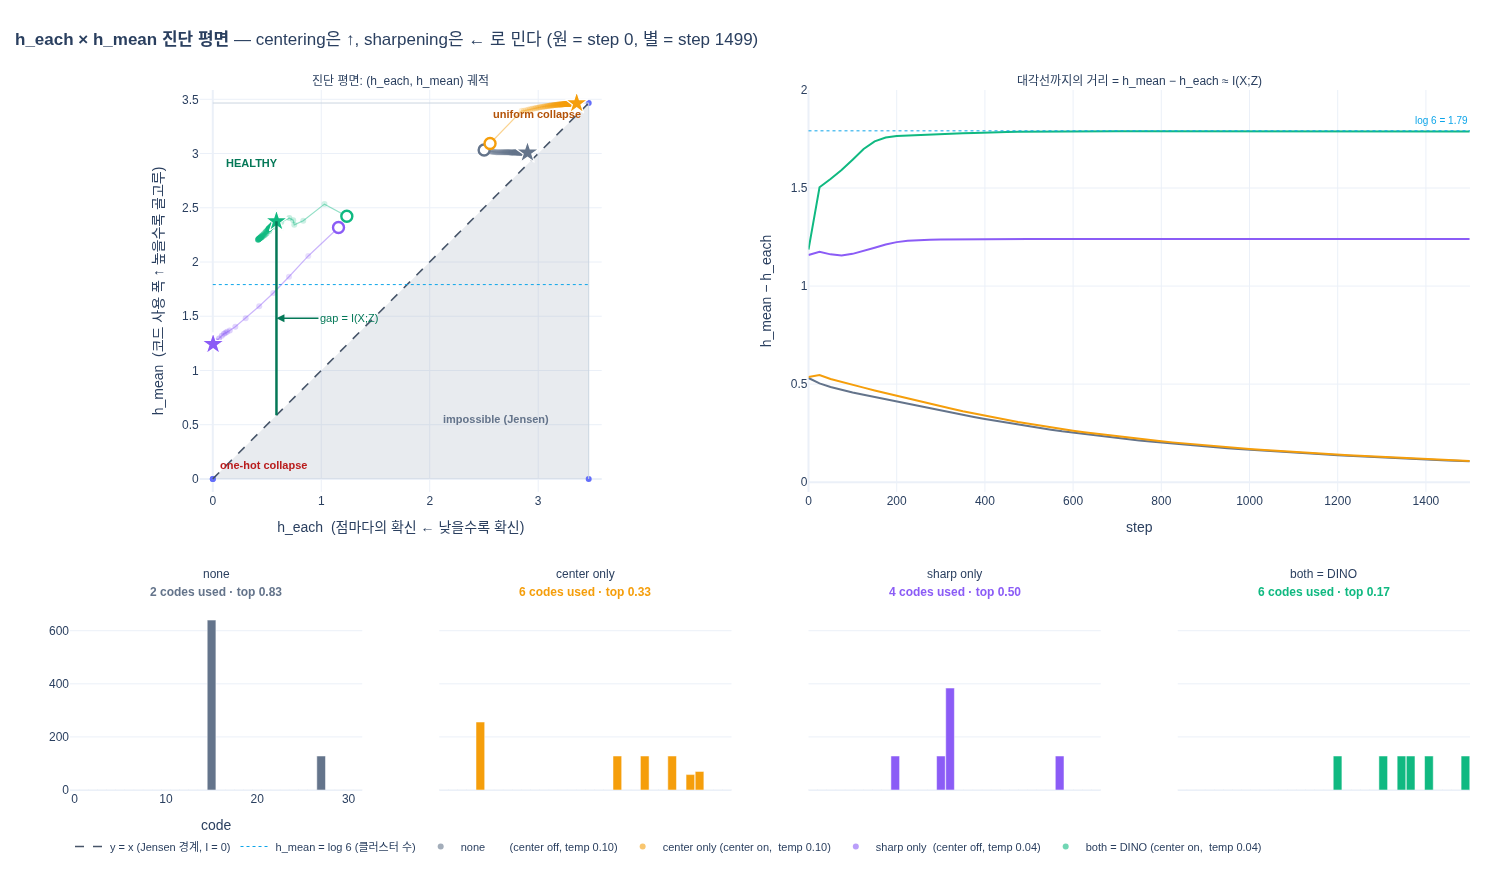

In [6]:
fig.update_xaxes(title_text="h_each  (점마다의 확신 ← 낮을수록 확신)", range=[-0.12, L + 0.12],
                 constrain="domain", row=1, col=1)
fig.update_yaxes(title_text="h_mean  (코드 사용 폭 ↑ 높을수록 골고루)", range=[-0.12, L + 0.12],
                 scaleanchor="x", scaleratio=1, constrain="domain", row=1, col=1)
fig.update_xaxes(title_text="step", row=1, col=3)
fig.update_yaxes(title_text="h_mean − h_each", range=[-0.05, 2.0], row=1, col=3)
for j in range(1, 5):
    fig.update_xaxes(title_text="code" if j == 1 else None, showticklabels=(j == 1), row=2, col=j)
    fig.update_yaxes(range=[0, 760], showticklabels=(j == 1), row=2, col=j)
    fig.update_yaxes(range=[0, 780], showticklabels=(j == 1), row=2, col=j)

fig.update_layout(
    height=880, width=1500, template="plotly_white",
    title=dict(text="<b>h_each × h_mean 진단 평면</b> — centering은 ↑, sharpening은 ← 로 민다 "
                    "(원 = step 0, 별 = step 1499)", x=0.01, font=dict(size=17)),
    legend=dict(orientation="h", y=-0.06, x=0.0, font=dict(size=11)),
    margin=dict(l=70, r=30, t=90, b=90), bargap=0.05,
)
for a in fig.layout.annotations[:6]:
    a.font.size = 12

fig.write_image("/home/sungwoo/projects/swcho/dino/fm/entropy/.fm/hints/1cf88fa6-313f-4416-8828-076fe7db6a8b/expy.png",
                scale=2)
print("saved expy.png")
_show(fig)

## 5. 판독

| 설정 | 최종 (h_each, h_mean) | 평면에서의 위치 | 판정 |
|---|---|---|---|
| none | (2.90, 3.01) | 대각선에 **딱 붙은** 우상단 | gap 0.11 — 정보 거의 없음 (코드 2개) |
| center only | (3.36, 3.46) | $(\log K, \log K)$ 코너 | **균등 붕괴** (gap 0.11) |
| sharp only | (0.00, 1.24) | 좌하단, 대각선에서 1.24 | 확신은 있으나 코드 4개(한 코드가 50%) — **원-핫 붕괴 진행 중** |
| both = DINO | (0.59, 2.38) | **좌상단**, 대각선에서 1.79 | 건강 (6 코드 = 6 클러스터, acc 1.00) |

- `none` → `center only`: y가 3.01 → 3.46으로 **위로** 밀린다 (centering이 h_mean을 올린다, +0.46).
- `none` → `sharp only`: x가 2.90 → 0.00으로 **왼쪽으로** 밀린다 (sharpening이 h_each를 내린다, −2.90).
- 두 장치를 같이 걸면 두 방향이 합성되어 좌상단(건강 영역)에 도달한다.
- gap의 상한은 $\log(\text{클러스터 수}) = 1.792$인데 `both`가 1.789 — 사실상 상한을 친다.

In [7]:
print("centering 효과 (y 이동):", f"{results['center only (center on,  temp 0.10)']['h_mean'][-1] - results['none        (center off, temp 0.10)']['h_mean'][-1]:+.3f}")
print("sharpening 효과 (x 이동):", f"{results['sharp only  (center off, temp 0.04)']['h_each'][-1] - results['none        (center off, temp 0.10)']['h_each'][-1]:+.3f}")
print("both의 대각선 거리:", f"{results['both = DINO (center on,  temp 0.04)']['h_mean'][-1] - results['both = DINO (center on,  temp 0.04)']['h_each'][-1]:.3f}  (상한 log 6 = 1.792)")

centering 효과 (y 이동): +0.455
sharpening 효과 (x 이동): -2.898
both의 대각선 거리: 1.789  (상한 log 6 = 1.792)
